# 🟠 TP2 | Projeto de Bloco: Inteligência Artificial e Machine Learning

**Objetivo:** Este projeto tem como objetivo proporcionar aos alunos experiência prática em técnicas de Processamento de Linguagem Natural (NLP) e Machine Learning, aplicadas a conjuntos de dados textuais.

Base de dados: [Fake.BR - Corpus](https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv)

## ⤵️ Imports

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [34]:
raw_data = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv')

In [35]:
raw_data.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


In [36]:
X = raw_data['preprocessed_news'].fillna('').astype(str).str.lower()
y = raw_data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

## ⏳ Criação das features

#### 📍 Computar o Term Frequency-Inverse Document Frequency (TF-IDF) para representar a importância das palavras em um conjunto de documentos.

**🗣️ Comentários:**

Antes de vetorizar os termos, realizamos alguns tratamentos:
* Preenchemos valores nulos com strings vazias;
* Transformamos todos os termos em lowerCase.

Além disso, fizemos alguns ajustes na vetorização em relação as stop_words:
* min_df e max_df em 1% e 99%, respectivamente;
* stop_words da língua inglesa.

In [37]:
tfidf_vectorizer = TfidfVectorizer(
  max_df = 0.99,
  min_df=0.01,
  stop_words='english'
)

X_vec = tfidf_vectorizer.fit_transform(X_train)
feature_names = tfidf_vectorizer.get_feature_names_out()

## ✴️ Modelagem de K-Nearest Neighbors (KNN)

#### 📍 Criar modelos simples de classificação utilizando a base de dados codificada por TF-IDF.

Explore diferentes valores para o parâmetro K do KNN e analise seu impacto nos resultados obtidos (através da acurácia do modelo para os dados de validação).

## ☑️ Avaliação de Modelos

#### 📍 Aplicar técnicas de validação cruzada para estimar a eficiência dos modelos desenvolvidos.

In [38]:
k_values = np.linspace(1, 50, 50, dtype=int)
result_list = []

In [39]:
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_vec, y_train)
  results = cross_val_score(knn, X_vec, y_train, cv=5, scoring='accuracy')
  result_list.append([k, results, results.mean(), results.std()])

In [40]:
df_results = pd.DataFrame(result_list, columns=['k_neighbors', 'cv_scores', 'mean_accuracy', 'std_accuracy'])

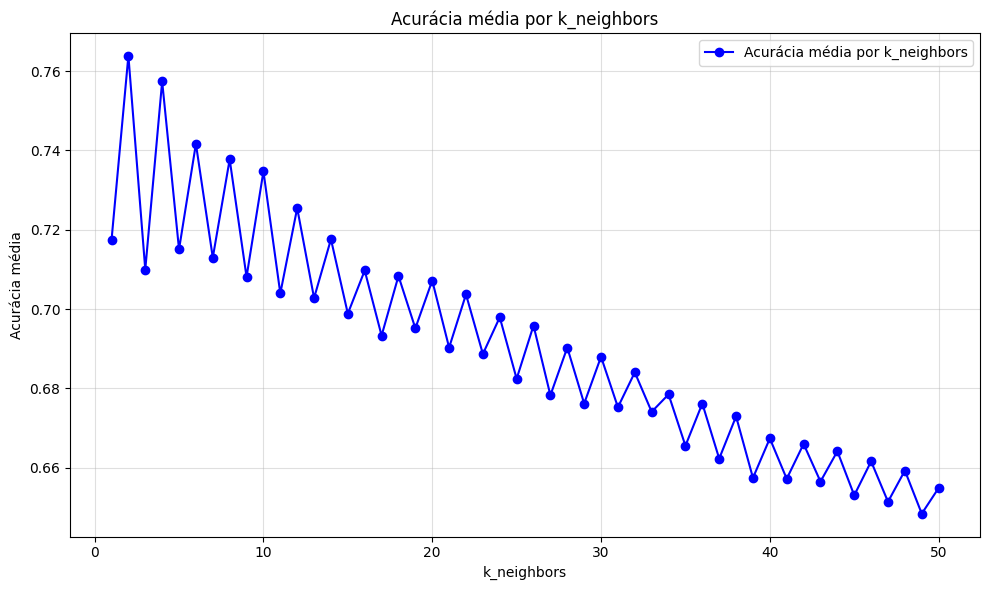

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(df_results['k_neighbors'], df_results['mean_accuracy'], color='blue', marker='o', label='Acurácia média por k_neighbors')

plt.grid(alpha=0.4)
plt.title('Acurácia média por k_neighbors')
plt.xlabel('k_neighbors')
plt.ylabel('Acurácia média')

plt.tight_layout()
plt.legend()
plt.show()

**🗣️ Comentários:**

Na etapa de separação dos dados (train_test_split), realizamos a divisão das bases:
* Treino (80%)
* Teste (20%)

Para o treinamento do modelo KNN, realizamos o treinamento com diferentes valores para k_neighbors (entre 1 a 50).

Na fase de validação cruzada, realizamos o cálculo da eficiência dos modelos com 5 folds.

A partir disso, calculamos a acurácia e desvio padrão para cada valor de k_neighbors.

Por fim, plotamos em um gráfico os valores de k_neighbors e suas respectivas acurácias médias. Assim, identificando que o melhor valor k_neightbors = 2.

## ☑️ Avaliação de Classificadores Binários

#### 📍 Utilizar figuras de mérito como Curva ROC, precisão, recall, f1-score, sensibilidade e especificidade para avaliar os modelos.


--- Classification Report ---
              precision    recall  f1-score   support

        fake       0.81      0.72      0.76      1440
        true       0.75      0.83      0.79      1440

    accuracy                           0.78      2880
   macro avg       0.78      0.78      0.78      2880
weighted avg       0.78      0.78      0.78      2880


AUC Score: 0.7909


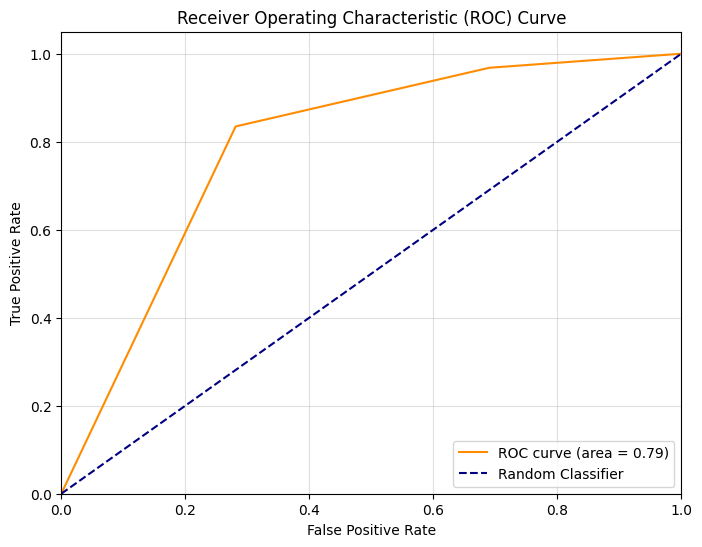

In [42]:
X_test_vec = tfidf_vectorizer.transform(X_test)

best_k = 2
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_vec, y_train)

y_pred = knn_final.predict(X_test_vec)

if 'true' in knn_final.classes_:
    pos_label_idx = list(knn_final.classes_).index('true')
    y_proba = knn_final.predict_proba(X_test_vec)[:, pos_label_idx]
else:
    y_proba = knn_final.predict_proba(X_test_vec)[:, 1]


print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=knn_final.classes_))

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label='true')
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC Score: {roc_auc:.4f}")

# --- Plot ROC Curve ---

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()

In [45]:
# --- Metrics for Training Data ---
y_train_pred = knn_final.predict(X_vec)
cm_train = confusion_matrix(y_train, y_train_pred, labels=['fake', 'true'])
TN_train, FP_train, FN_train, TP_train = cm_train.ravel()

sensitivity_train = TP_train / (TP_train + FN_train)
specificity_train = TN_train / (TN_train + FP_train)

print("\n--- Training Data Metrics ---")
print(f"Sensitivity (Recall for 'true' class): {sensitivity_train:.4f}")
print(f"Specificity (Recall for 'fake' class): {specificity_train:.4f}")

# --- Metrics for Test Data ---
cm_test = confusion_matrix(y_test, y_pred, labels=['fake', 'true'])
TN_test, FP_test, FN_test, TP_test = cm_test.ravel()

sensitivity_test = TP_test / (TP_test + FN_test)
specificity_test = TN_test / (TN_test + FP_test)

print("\n--- Test Data Metrics ---")
print(f"Sensitivity (Recall for 'true' class): {sensitivity_test:.4f}")
print(f"Specificity (Recall for 'fake' class): {specificity_test:.4f}")


--- Training Data Metrics ---
Sensitivity (Recall for 'true' class): 0.9171
Specificity (Recall for 'fake' class): 1.0000

--- Test Data Metrics ---
Sensitivity (Recall for 'true' class): 0.8347
Specificity (Recall for 'fake' class): 0.7188


## 🗣️ Conclusão

#### 📍 Baseado nos valores encontrados para as diferentes figuras de mérito, interprete os resultados e disserte sobre a eficiência do classificador criado.

O modelo KNN com k=2 apresentou bom desempenho na tarefa de classificação de notícias, sendo capaz de identificar padrões relevantes a partir da representação TF-IDF. As métricas de avaliação indicam um equilíbrio adequado entre precisão e recall, refletido também em um F1-score consistente.

A análise da curva ROC e do AUC demonstra que o modelo possui uma boa capacidade de separação entre as classes, superando o comportamento de um classificador aleatório.

Além disso, a análise de sensibilidade e especificidade mostrou que o modelo apresentou excelente desempenho nos dados de treinamento, com sensibilidade de 91,71% e especificidade de 100%, indicando alta capacidade de identificar corretamente notícias verdadeiras e falsas. Nos dados de teste, houve uma redução desses valores para 83,47% e 71,88%, respectivamente, o que era esperado devido à generalização para dados não vistos. Apesar dessa queda, os resultados permanecem satisfatórios, demonstrando que o modelo mantém boa capacidade de detecção da classe positiva (notícias verdadeiras), embora apresente maior dificuldade em reconhecer corretamente a classe negativa (notícias falsas), evidenciando espaço para melhorias na redução de falsos positivos.